In [2]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
sns.set()
import numpy as np

%load_ext rpy2.ipython

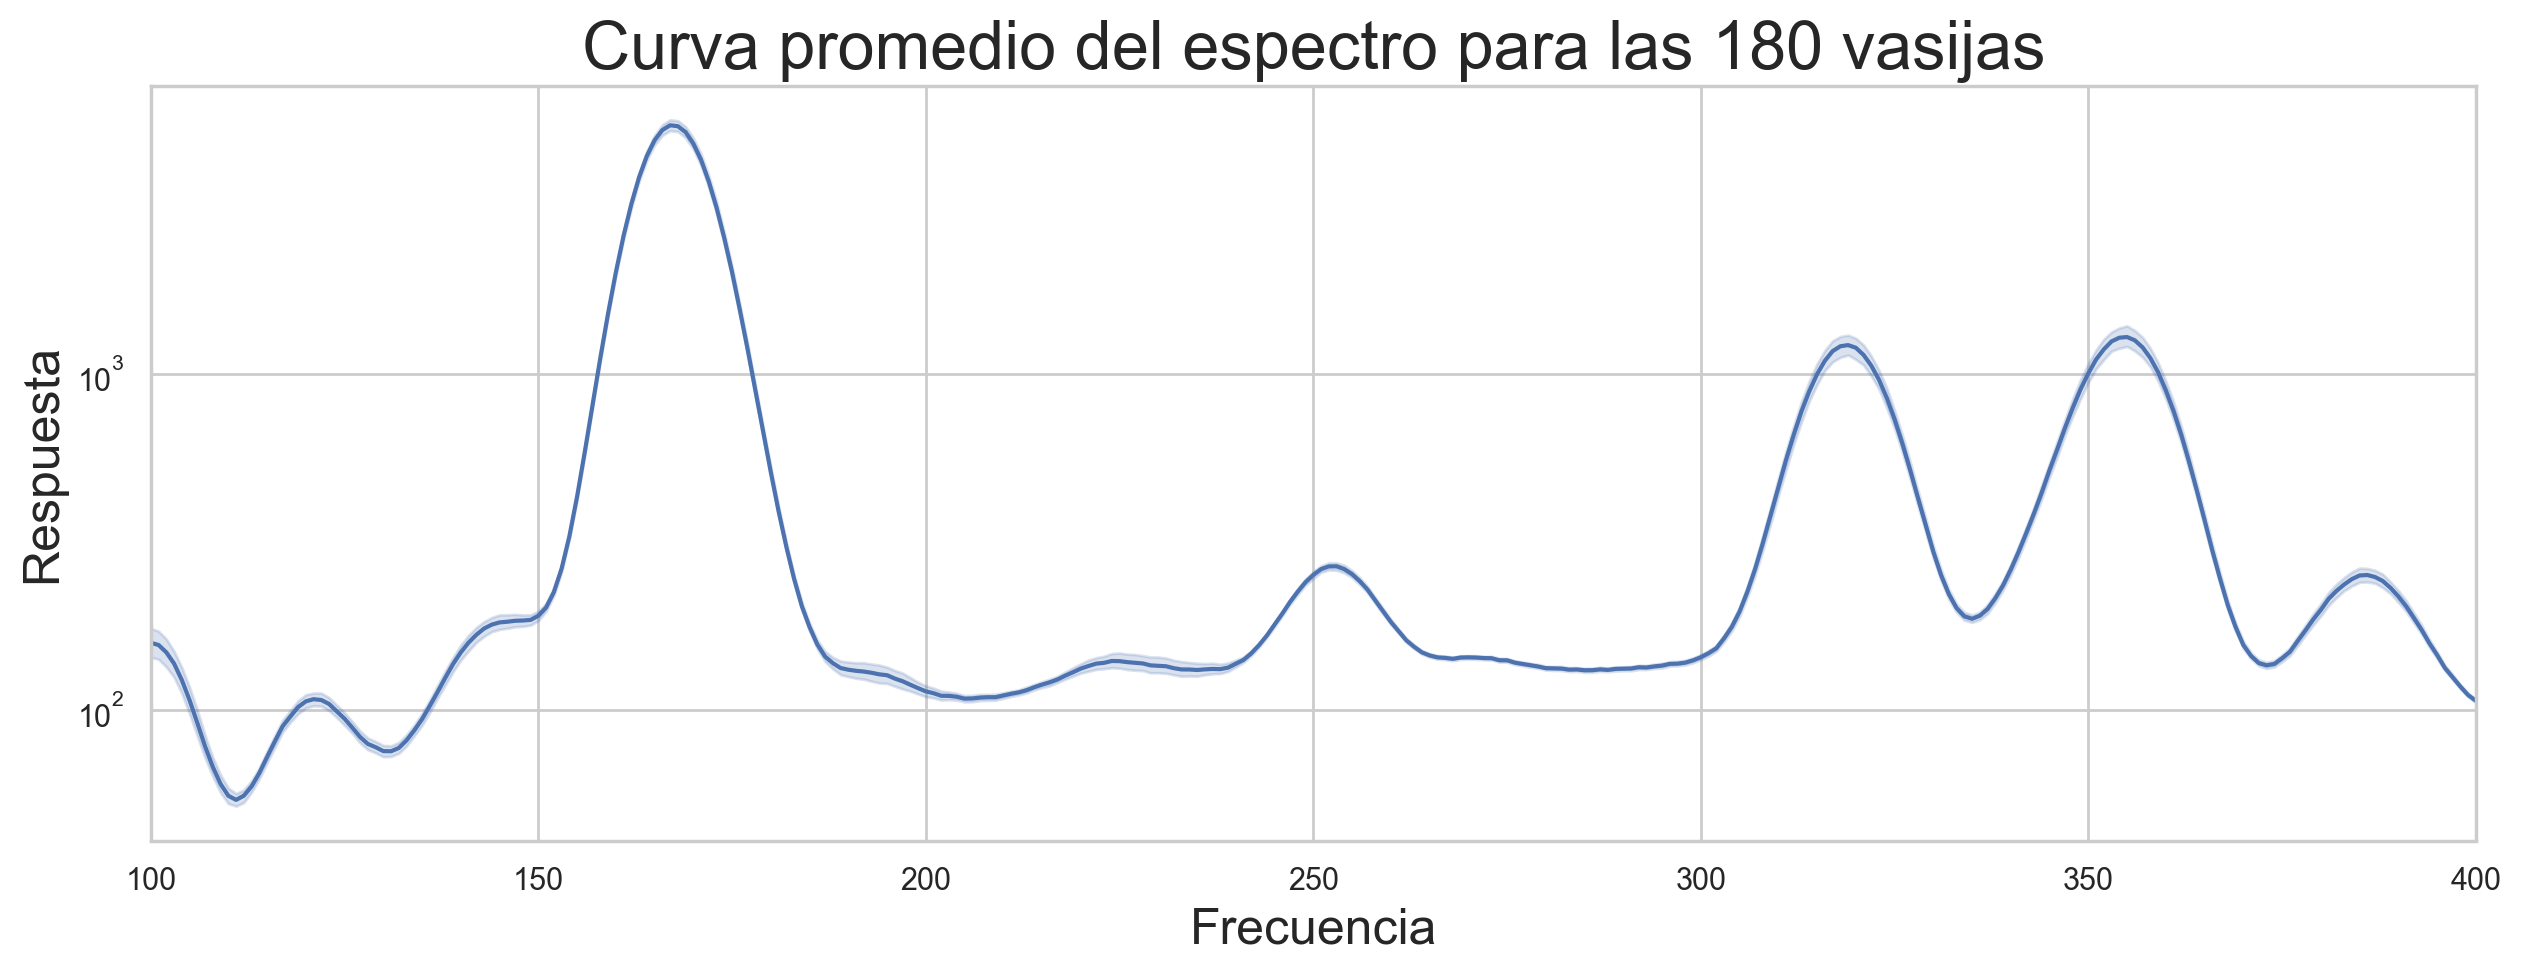

In [9]:
df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = range(100, 401)

a = df.stack().to_frame().reset_index()[['level_1', 0]]
a.columns = ["frecuencia", "respuesta"]

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(15, 5))
plt.title("Curva promedio del espectro para las 180 vasijas", fontsize=24)

sns.lineplot(x="frecuencia", y="respuesta", data=a, ax=ax).set(yscale='log')
ax.set_xlim(100, 400)

ax.set_xlabel("Frecuencia", fontsize=18)
ax.set_ylabel("Respuesta", fontsize=18)
plt.show()

In [11]:
df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]
Y = pd.read_csv("Vessel_Y.txt", header=None)
dfY = df.copy()
dfY['Y'] = Y.loc[:,0]

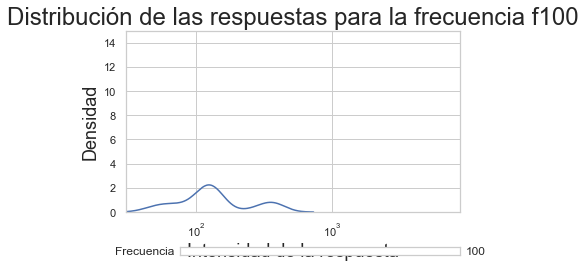

In [284]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

sns.set_theme(style="whitegrid")

df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]


fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update(val):
    ax.clear()
    ax.set_xlim(df.min().min(), df.max().max())
    ax.set_ylim(0, 15)
    ax.set_xlabel("Intensidad de la respuesta", fontsize=18)
    ax.set_ylabel("Densidad", fontsize=18)
    freq = 'f' + str(int(val))
    ax.set_title("Distribución de las respuestas para la frecuencia " + freq, fontsize=24)
    sns.kdeplot(np.array(df[freq]), ax=ax, log_scale=True)

axfreq = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axfreq,
    label='Frecuencia',
    valmin=100,
    valmax=400,
    valinit=100,
    valfmt='%0.0f',
)
freq_slider.on_changed(update)

update(freq_slider.valinit)
plt.show()

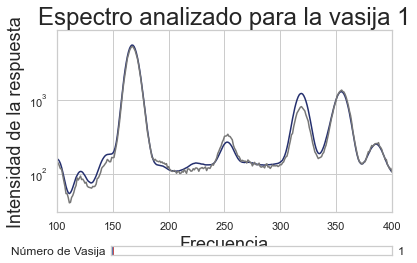

In [295]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button


sns.set_theme(style="whitegrid")

df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update(val):
    ax.clear()
    ax.set_xlim(100, 400)
    ax.set_ylim(df.min().min(), df.max().max())
    
    ax.set_xlabel("Frecuencia", fontsize=18)
    ax.set_ylabel("Intensidad de la respuesta", fontsize=18)
    ax.set_title("Espectro analizado para la vasija " + str(int(val)), fontsize=24)

    sns.lineplot(x=range(100, 401), y=df.mean(), ax=ax, color='#242F6E')
    sns.lineplot(x=range(100, 401), y=df.loc[int(val)], ax=ax, color='#777777')

axvasj = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axvasj,
    label='Número de Vasija',
    valmin=0,
    valmax=179,
    valinit=1,
    valfmt='%0.0f',
)

freq_slider.on_changed(update)

update(freq_slider.valinit)
plt.show()

In [132]:
import matplotlib.colors

[]

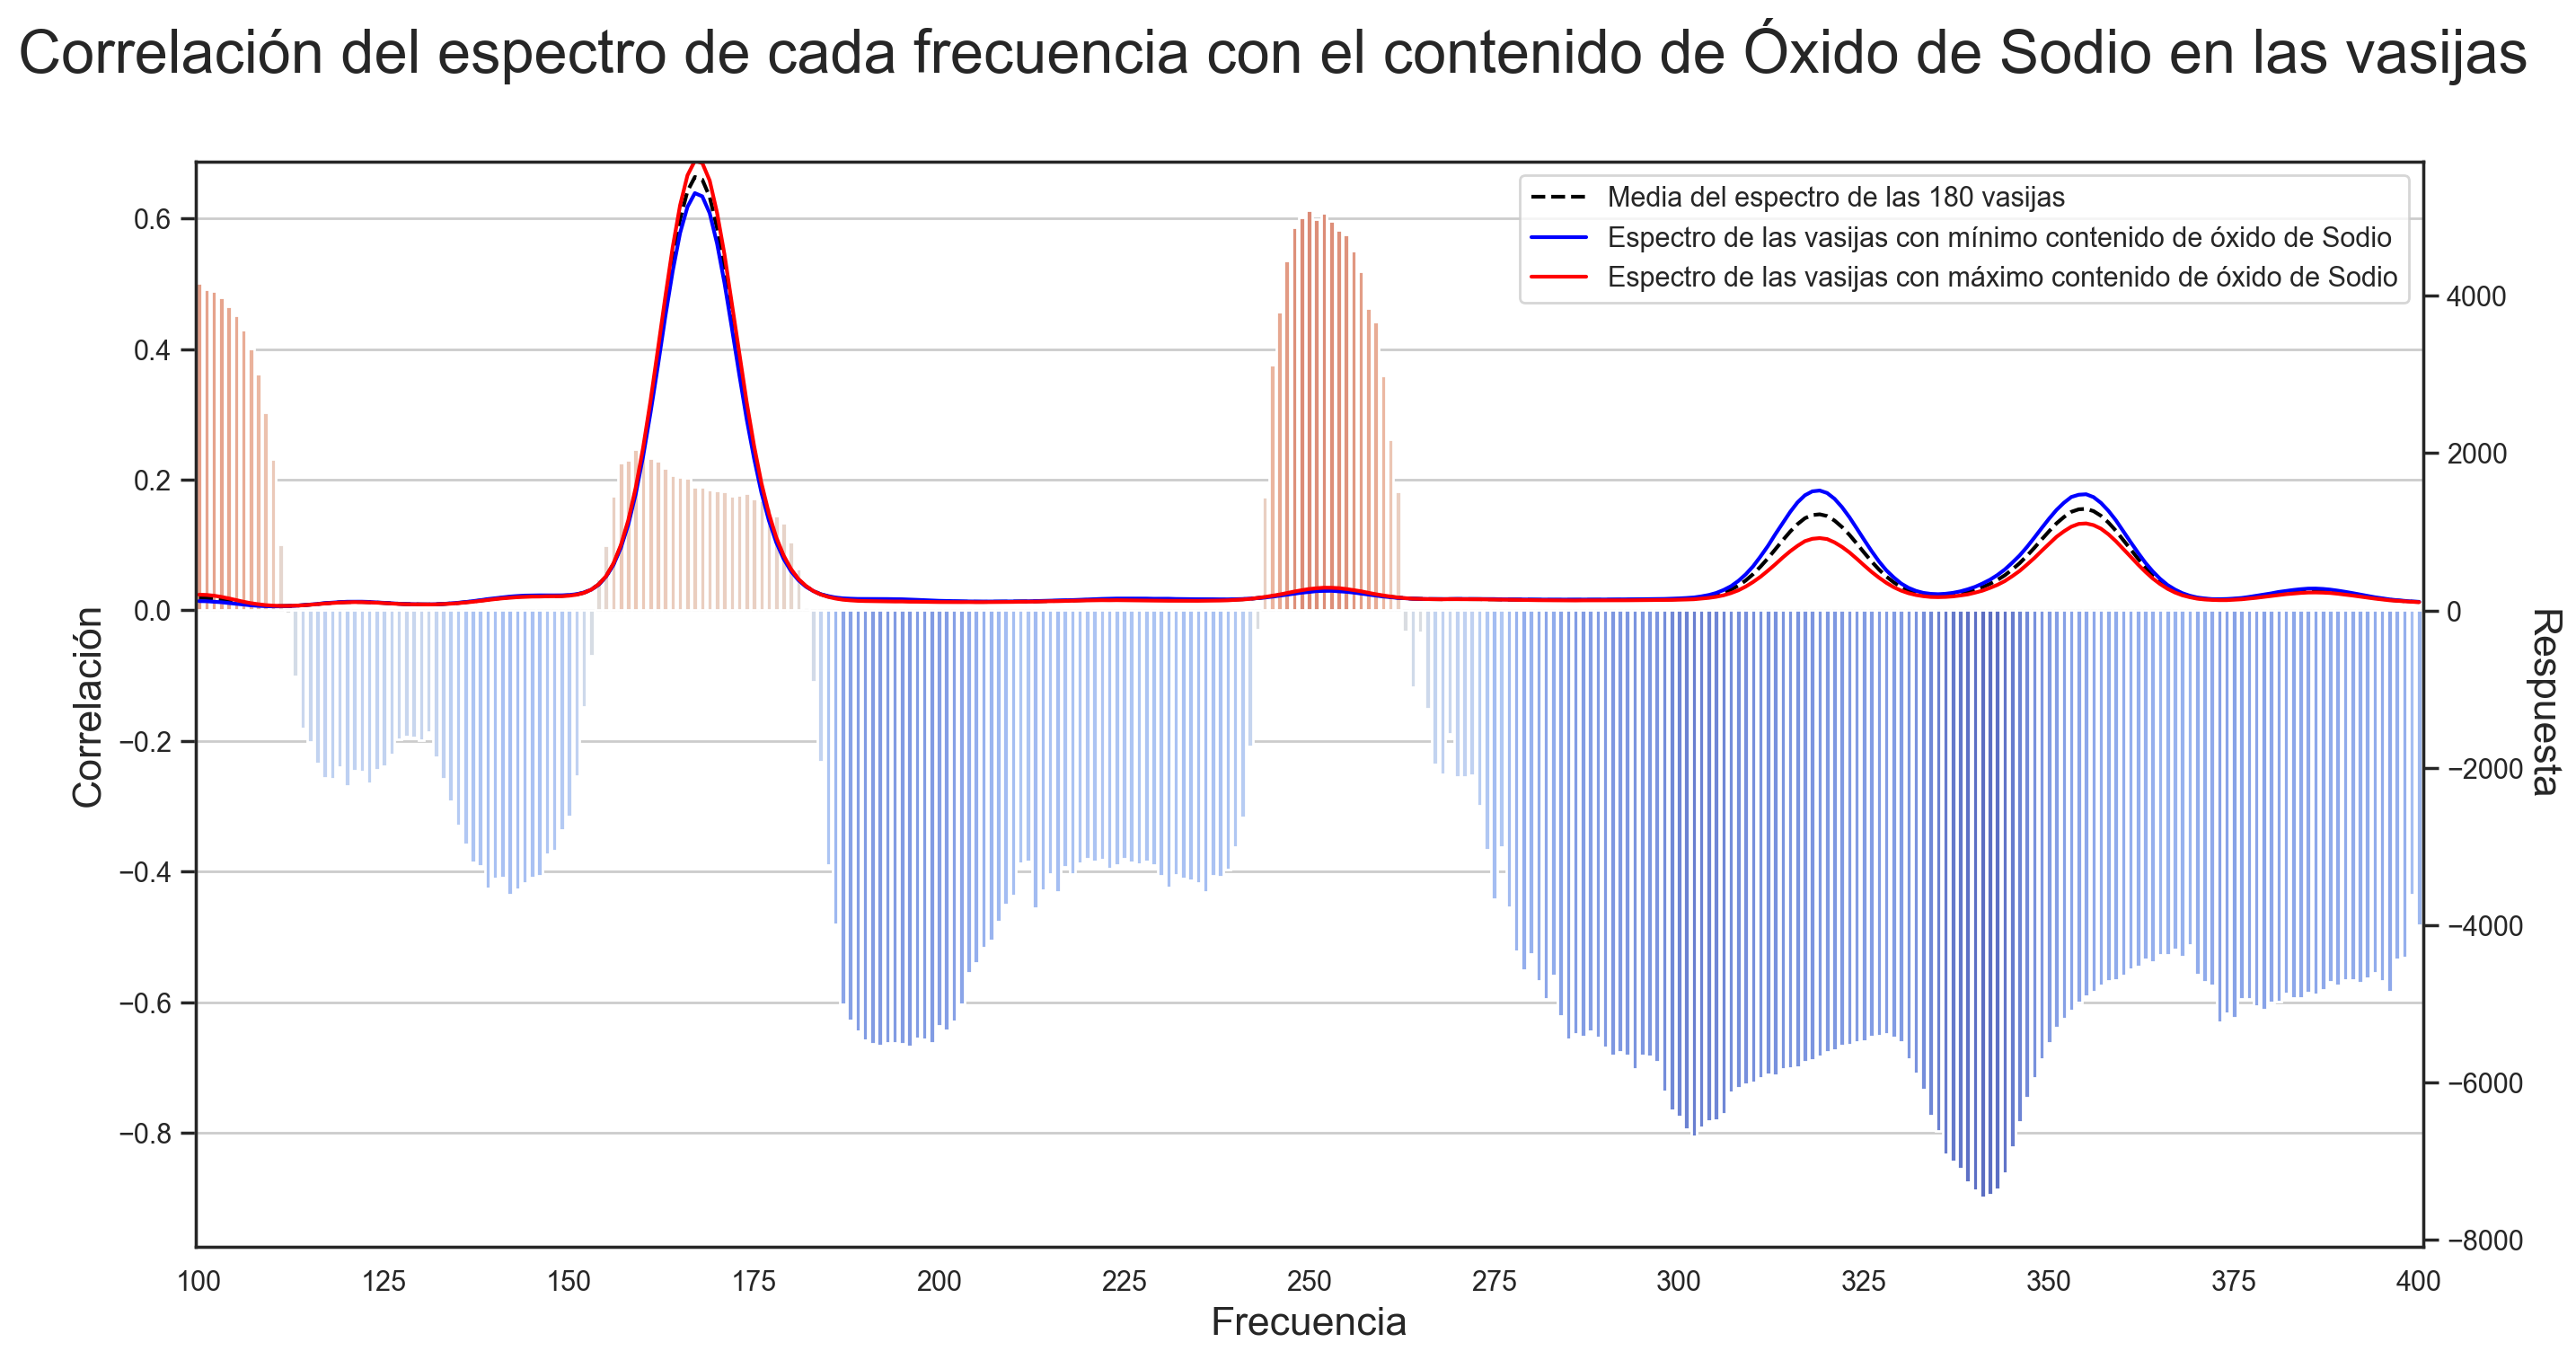

In [107]:
corrs = dfY.corr()['Y'].drop('Y')

sns.set_theme(style="whitegrid")

cmap = plt.cm.coolwarm
colores = [cmap(i) for i in range(cmap.N)]
coloresplot = [colores[int(128 + y*128)] for y in pd.Series(corrs)]


fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))
sns.set_theme(style="ticks", palette="flare")


ax.set_xlim(100, 400)

sns.barplot(x=list(range(100, 401)),
            y=pd.Series(corrs),
            palette=coloresplot,
            ax=ax)

ax2 = ax.twinx()
ax2.set_ylim(-1.416*(max(df.mean())+200), max(df.mean()) + 200)

maxidx = (-dfY['Y']).argsort()[:int(len(dfY['Y'])/2)]
minidx = (-dfY['Y']).argsort()[int(len(dfY['Y'])/2):]

sns.lineplot(x=list(range(0, 301)),
             y=df.mean(),
             ax=ax2,
             color='#000000',
             label="Media del espectro de las 180 vasijas").lines[0].set_linestyle("--")
sns.lineplot(x=list(range(0, 301)),
             y=np.mean(df.loc[minidx]),
             ax=ax2,
             color='blue',
             label="Espectro de las vasijas con mínimo contenido de óxido de Sodio")
sns.lineplot(x=list(range(0, 301)),
             y=np.mean(df.loc[maxidx]),
             ax=ax2,
             color='red',
             label="Espectro de las vasijas con máximo contenido de óxido de Sodio")

ax.set_xticklabels([t if not i%25 else "" for i,t in enumerate(ax.get_xticklabels())])


plt.suptitle('Correlación del espectro de cada frecuencia con el contenido de Óxido de Sodio en las vasijas', fontsize=24)
ax.set_xlabel("Frecuencia", fontsize=16)
ax.set_ylabel("Correlación", fontsize=16)
ax2.set_ylabel("Respuesta", fontsize=16, rotation=-90, labelpad=14)

plt.plot()

<AxesSubplot:ylabel='59'>

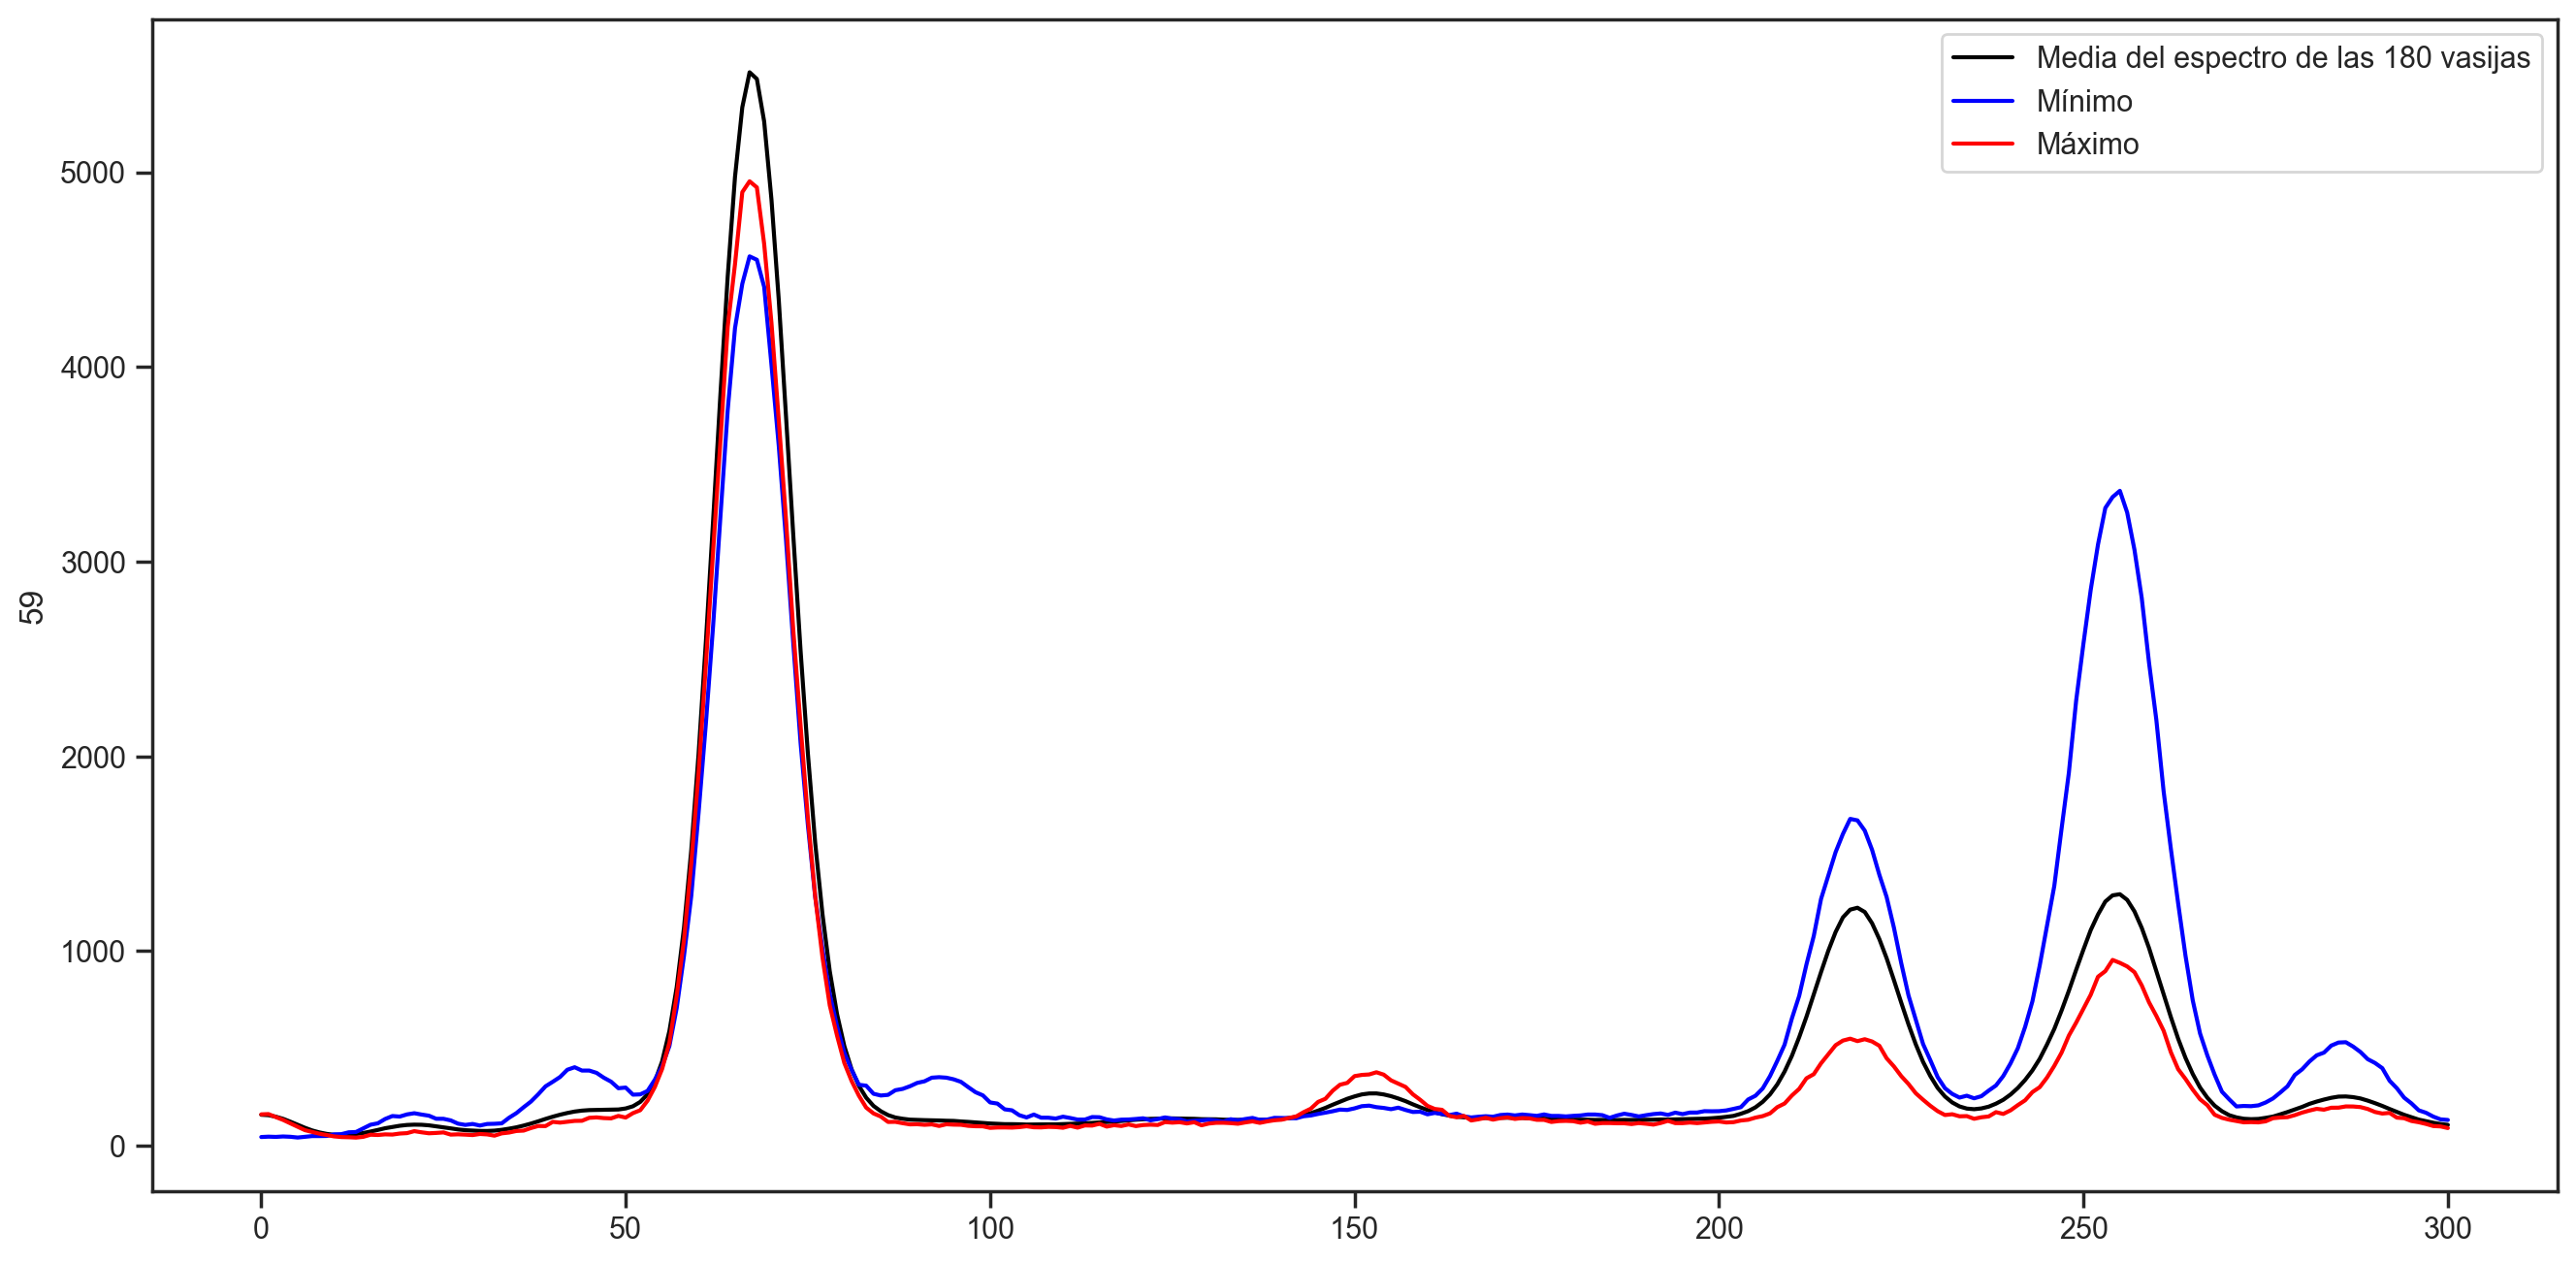

In [67]:

fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))

sns.lineplot(x=list(range(0, 301)),
             y=df.mean(),
             ax=ax,
             color='#000000',
             label="Media del espectro de las 180 vasijas")

[]

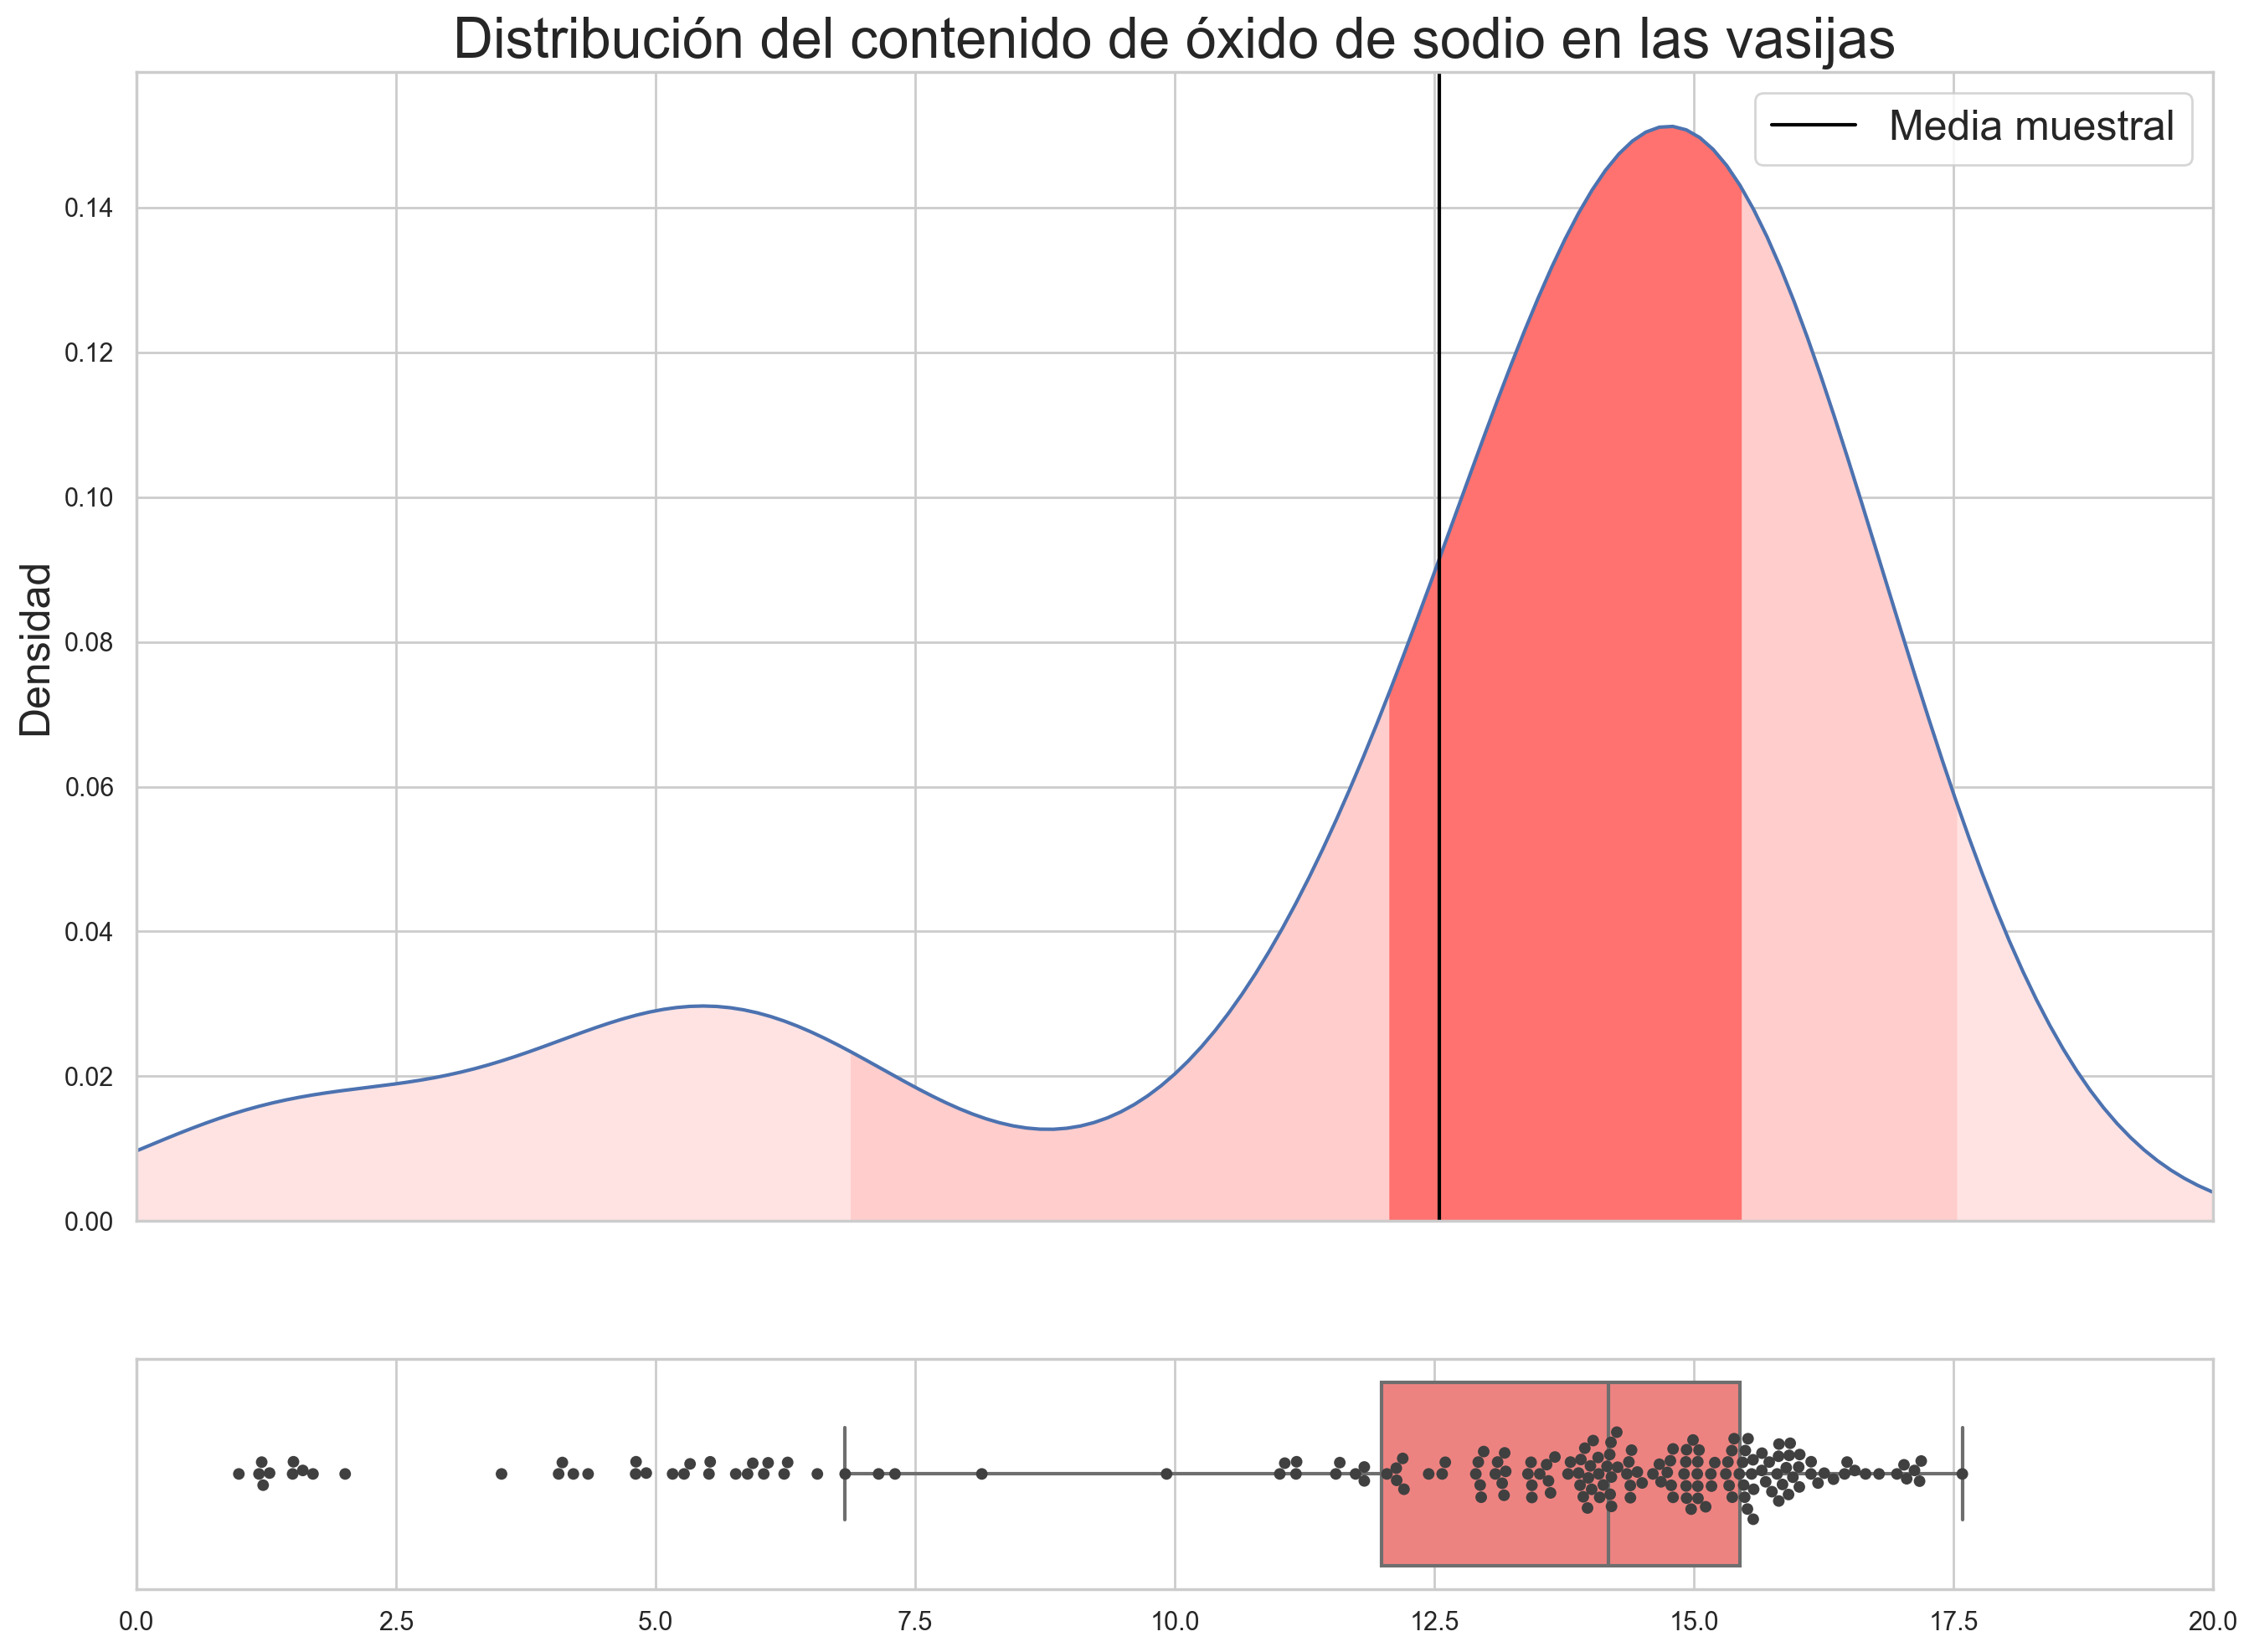

In [35]:
sns.set_theme(style="whitegrid")

fig, (ax_dty, ax_box) = plt.subplots(nrows=2, ncols=1, dpi=200, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [5, 1]})

sns.boxplot(x=np.array(dfY['Y']), ax=ax_box, orient="h", fliersize=0, palette=['#FF726F'])
sns.swarmplot(x=np.array(dfY['Y']), color=".25", ax=ax_box)

ax_dty=sns.kdeplot(np.array(dfY['Y']), ax=ax_dty)

ax_dty.set_xlim(0, 20)
ax_dty.set_ylabel("Densidad", fontsize=18)
ax_dty.set_xlabel("Contenido de óxido de sodio", fontsize=18)
ax_dty.set_title('Distribución del contenido de óxido de sodio en las vasijas', fontsize=24)

kde_x, kde_y = ax_dty.lines[0].get_data()
q25 = np.quantile(dfY['Y'], 0.25)
q50 = np.quantile(dfY['Y'], 0.5)
q75 = np.quantile(dfY['Y'], 0.75)
minbox = max(q25 - 1.5*(q75-q25), min(dfY['Y']))
maxbox = min(q75 + 1.5*(q75-q25), max(dfY['Y']))
ax_dty.fill_between(kde_x, kde_y, where=(kde_x<20)&(kde_x>0),  color='#FFE3E3')
ax_dty.fill_between(kde_x, kde_y, where=(kde_x<maxbox)&(kde_x>minbox),  color='#FFCDCC')
ax_dty.fill_between(kde_x, kde_y, where=(kde_x<q75)&(kde_x>q25), color='#FF726F')

ax_dty.axvline(x=np.mean(dfY['Y']), color="#000000", label="Media muestral")


ax_dty.legend(fontsize=18)

plt.plot()

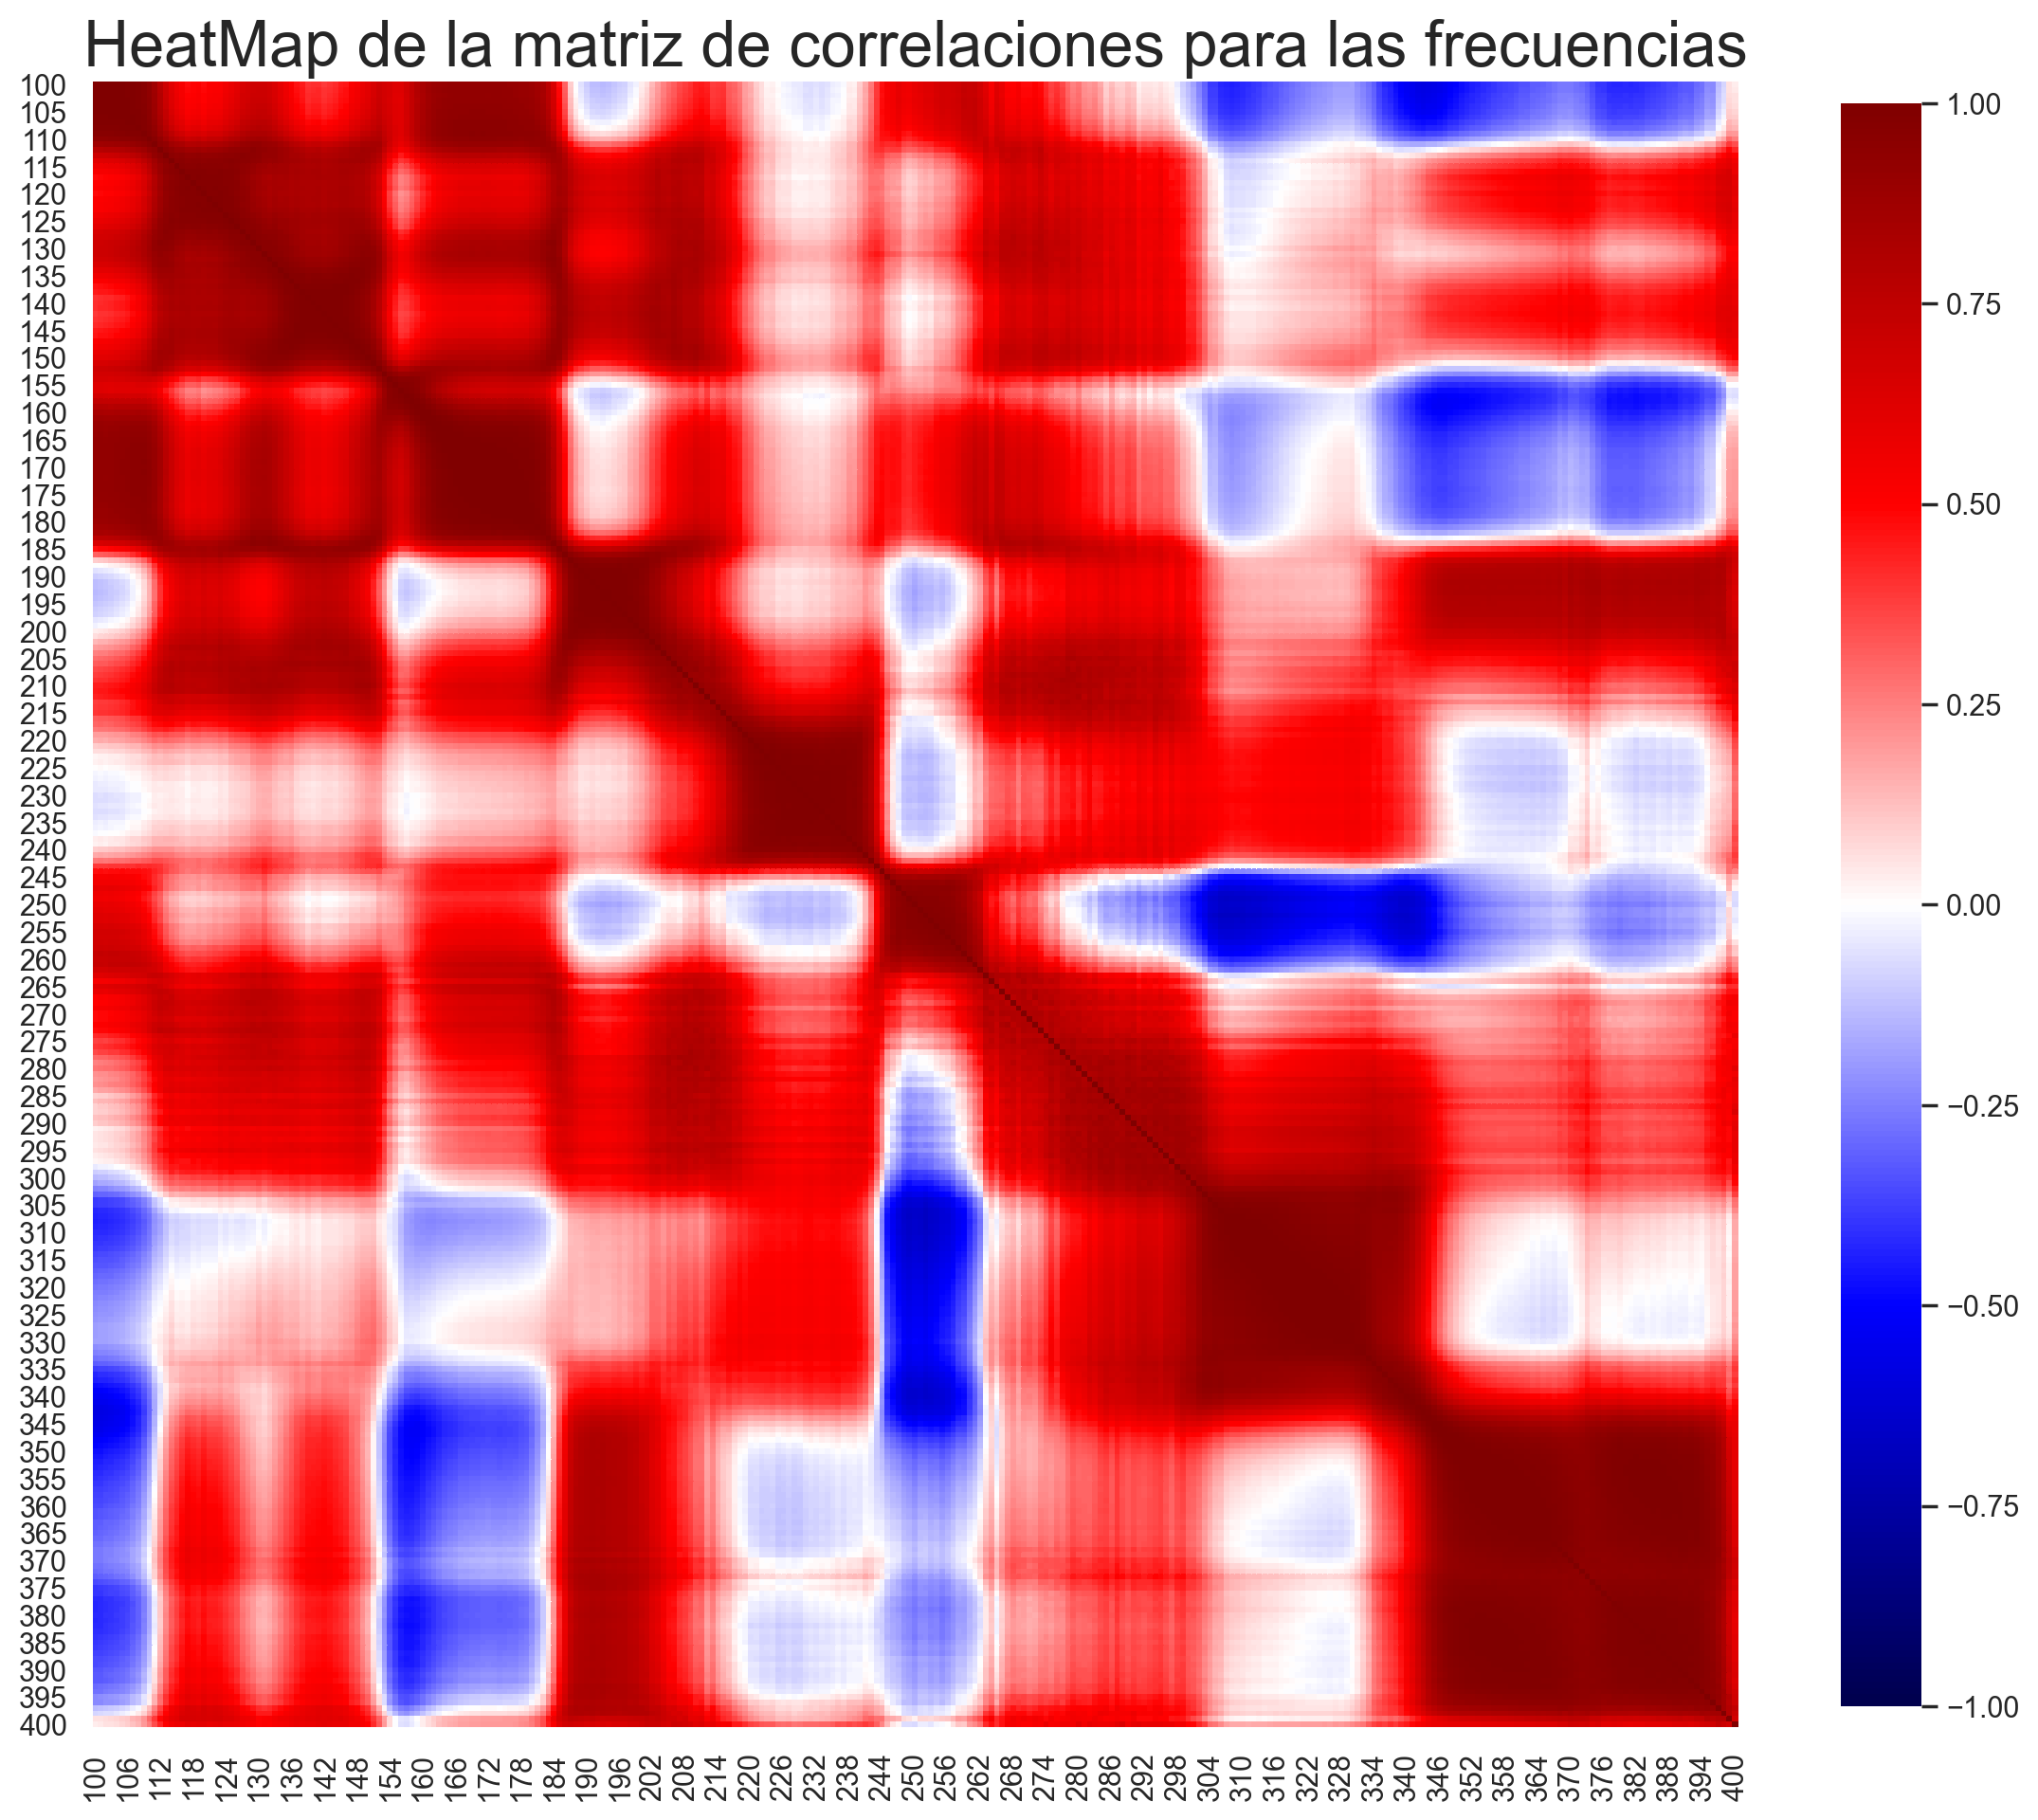

In [54]:
corrs = df.corr()

mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(dpi=200, figsize=(14, 14))
    ax = sns.heatmap(corrs, vmin=-1, vmax=1, square=True, cmap='seismic', cbar_kws={"shrink": 0.8})
    ax.set_title("HeatMap de la matriz de correlaciones para las frecuencias", size=24)

In [83]:
%%R
source("Utils.R")

preprocesamiento_agrupar <- function(X, tamanio_ventana) {
  if(tamanio_ventana==1){
      return(X)
  }
  X_means <- data.frame(matrix(NA, nrow = nrow(X), ncol = ceiling(ncol(X) / tamanio_ventana)))
  last_i <- floor(ncol(X) / tamanio_ventana)
  for (i in 1:last_i) {
    j <- i - 1
    X_means[,i] <- rowMeans(X[, (j * tamanio_ventana + 1): (i * tamanio_ventana)])
  }
  num_last_cols <- i * tamanio_ventana + ncol(X) %% tamanio_ventana
  num_first_last_cols <- last_i * tamanio_ventana + 1
  if(num_first_last_cols > num_last_cols){
      return(X_means)
  } else if(num_first_last_cols != num_last_cols) {
    X_means[,ceiling(ncol(X) / tamanio_ventana)] <- rowMeans(X[, num_first_last_cols: num_last_cols])
  } else {
    X_means[,ceiling(ncol(X) / tamanio_ventana)] <- X[, num_first_last_cols]
  }
  return (X_means)
}

setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

write.csv(preprocesamiento_agrupar(vasijas_X, 4), "/home/lukas/FIUBA/AE/Repositorio/trabajo_practico3/src/TRAIN_X/tmp.csv")
write.csv(vasijas_Y, "/home/lukas/FIUBA/AE/Repositorio/trabajo_practico3/src/TRAIN_Y/tmp.csv")

In [84]:
TRAIN_X = pd.read_csv("TRAIN_X/tmp.csv")
TRAIN_Y = pd.read_csv("TRAIN_Y/tmp.csv")
del TRAIN_X['Unnamed: 0']
del TRAIN_Y['Unnamed: 0']
TRAIN_X.columns = ['$V^{*}_{'+str(i)+'}$' for i in range(1, len(TRAIN_X.columns)+1)]

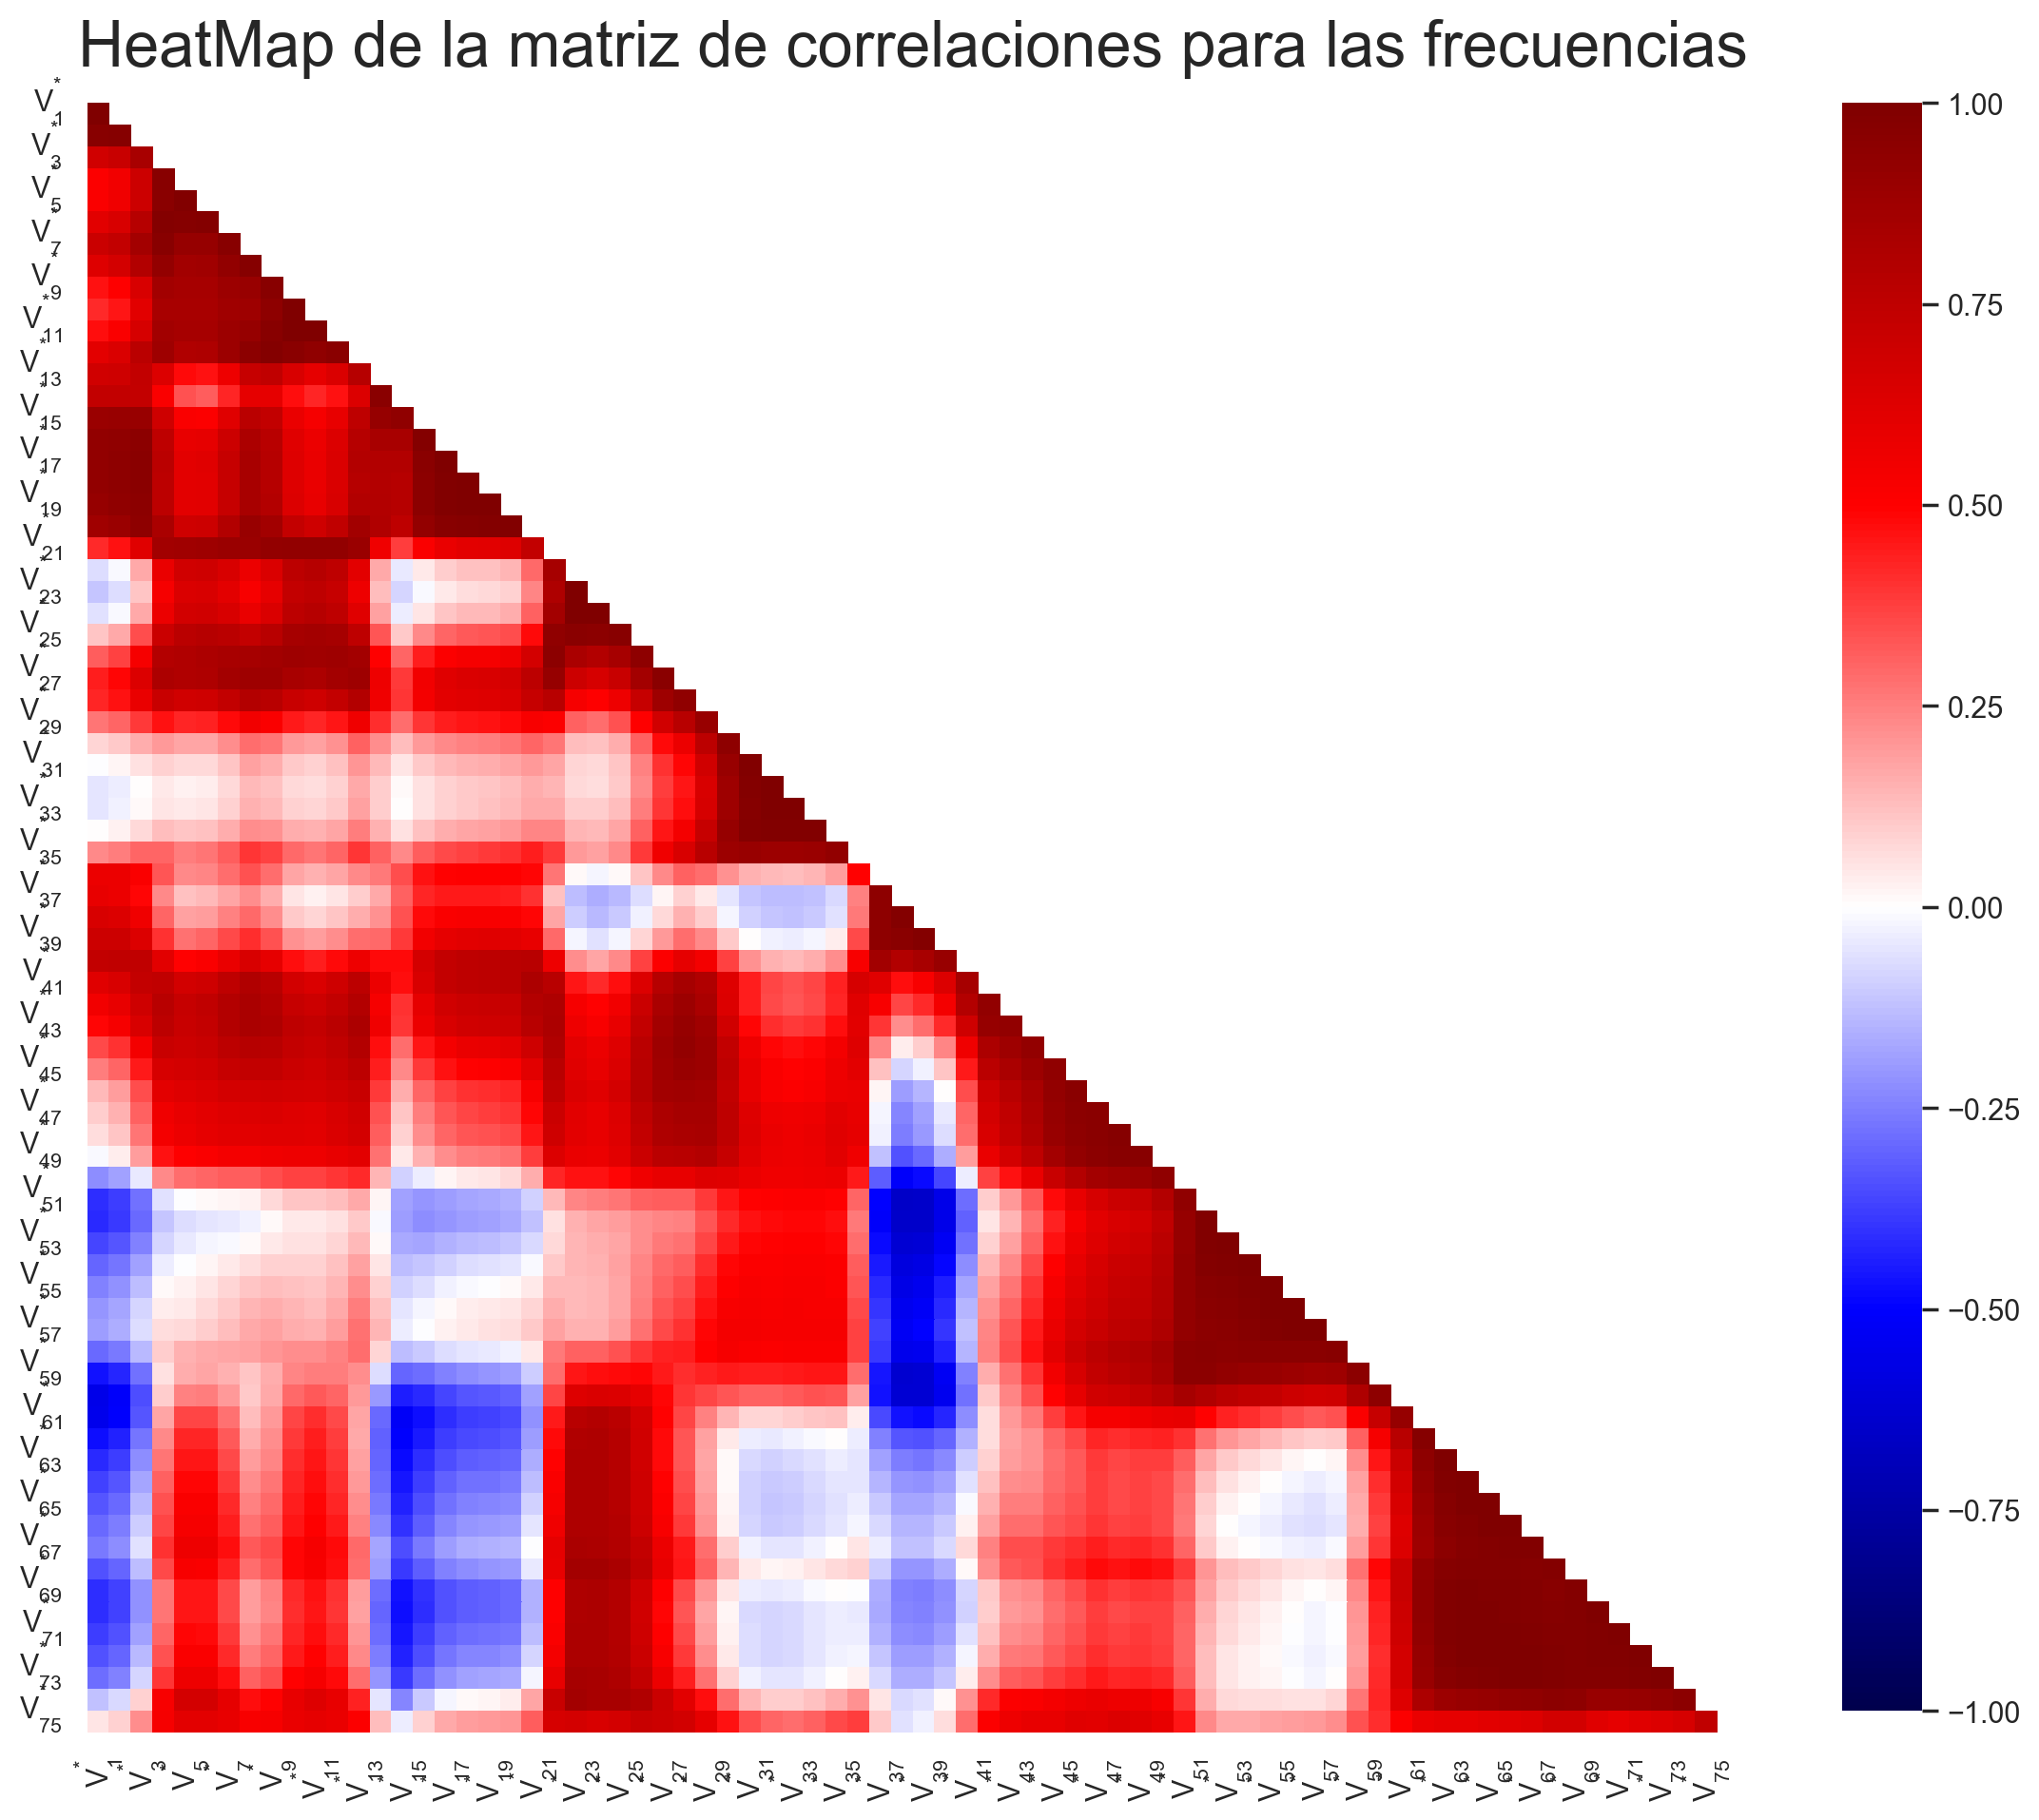

In [85]:
corrs = TRAIN_X.corr()
params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(dpi=200, figsize=(14, 14))
    ax = sns.heatmap(corrs, vmin=-1, vmax=1, square=True, cmap='seismic', cbar_kws={"shrink": 0.8}, mask=mask)
    ax.set_title("HeatMap de la matriz de correlaciones para las frecuencias", size=24)